In [ ]:
import pandas as pd

df = pd.read_csv("titanic.csv")

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [ ]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [ ]:
print("Sex:", df["Sex"].unique())
print("Embarked:", df["Embarked"].unique())

Sex: ['male' 'female']
Embarked: ['S' 'C' 'Q' nan]


In [ ]:
processed_df = df.copy()
processed_df["Sex"] = processed_df["Sex"].map({"male": 0, "female": 1})
print(processed_df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    0  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0   
2                             Heikkinen, Miss. Laina    1  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1      0   
4                           Allen, Mr. William Henry    0  35.0      0      0   

             Ticket     Fare Cabin Embarked  
0         A/5 21171   7.2500   NaN        S  
1          PC 17599  71.2833   C85        C  
2  STON/O2. 3101282   7.9250   NaN        S  
3            113803  53.1000  C123        S  
4            373450   8.0500   NaN        S  


In [ ]:
processed_df = pd.get_dummies(
    processed_df,
    columns=["Embarked"],
    dtype=int
)

print(processed_df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    0  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0   
2                             Heikkinen, Miss. Laina    1  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1      0   
4                           Allen, Mr. William Henry    0  35.0      0      0   

             Ticket     Fare Cabin  Embarked_C  Embarked_Q  Embarked_S  
0         A/5 21171   7.2500   NaN           0           0           1  
1          PC 17599  71.2833   C85           1           0           0  
2  STON/O2. 3101282   7.9250   NaN           0           0           1  
3   

In [7]:
import pandas as pd

df = pd.read_csv("titanic.csv")

In [8]:
processed_df = df.copy()

In [9]:
processed_df["Sex"] = processed_df["Sex"].map({
    "male": 0,
    "female": 1
})

In [10]:
processed_df = pd.get_dummies(
    processed_df,
    columns=["Embarked"],
    dtype=int
)

In [11]:
X = processed_df[
    [
        "Pclass",
        "Sex",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "Embarked_C",
        "Embarked_Q",
        "Embarked_S"
    ]
]

y = processed_df["Survived"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_C  Embarked_Q  \
0       3    0  22.0      1      0   7.2500           0           0   
1       1    1  38.0      1      0  71.2833           1           0   
2       3    1  26.0      0      0   7.9250           0           0   
3       1    1  35.0      1      0  53.1000           0           0   
4       3    0  35.0      0      0   8.0500           0           0   

   Embarked_S  
0           1  
1           0  
2           1  
3           1  
4           1  

Target (y):
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (712, 9)
X_test: (179, 9)
y_train: (712,)
y_test: (179,)


Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


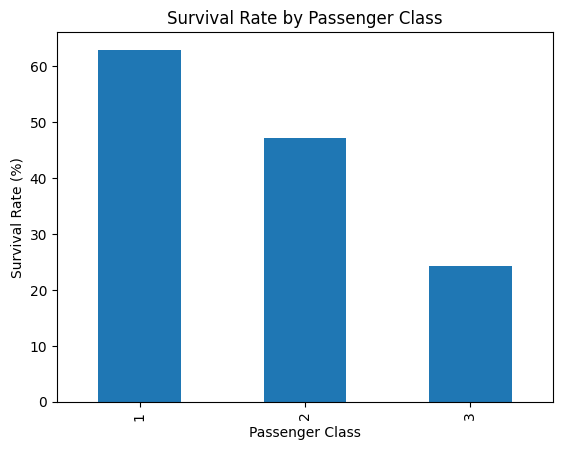

In [15]:
import matplotlib.pyplot as plt

survival_by_class = df.groupby("Pclass")["Survived"].mean() * 100

print(survival_by_class)

survival_by_class.plot(kind="bar")

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")

plt.show()

In [ ]:
## EDA Finding: Passenger Class

The analysis shows that passenger class was associated with survival rate. First-class passengers had the highest survival rate of approximately 63%, while third-class passengers had the lowest survival rate of approximately 24%. This suggests that passenger class may be an important feature for predicting survival.

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


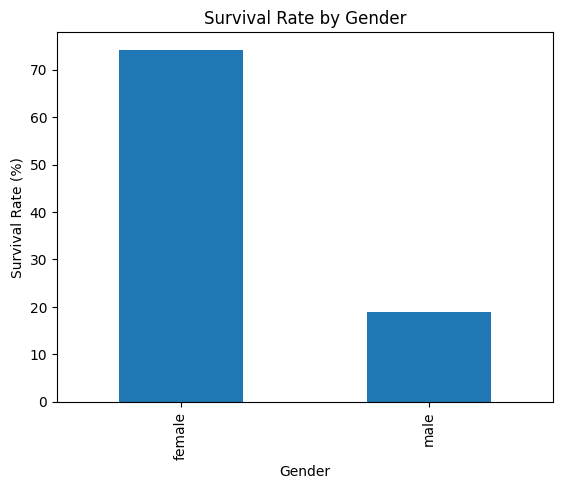

In [16]:
survival_by_gender = df.groupby("Sex")["Survived"].mean() * 100

print(survival_by_gender)

survival_by_gender.plot(kind="bar")

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")

plt.show()

In [ ]:
## EDA Finding: Gender

The analysis shows a significant difference in survival rates between female and male passengers. Approximately 74% of female passengers survived, compared with approximately 19% of male passengers. This suggests that gender may be an important feature for predicting survival.

In [17]:
print("Missing values:")
print(X.isnull().sum())

print("\nData types:")
print(X.dtypes)

Missing values:
Pclass          0
Sex             0
Age           177
SibSp           0
Parch           0
Fare            0
Embarked_C      0
Embarked_Q      0
Embarked_S      0
dtype: int64

Data types:
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_C      int64
Embarked_Q      int64
Embarked_S      int64
dtype: object


In [18]:
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (891, 9)
y shape: (891,)


In [19]:
final_df = X.copy()
final_df["Survived"] = y

final_df.to_csv("titanic_processed.csv", index=False)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


In [ ]:
# Day 2 — Data Preprocessing and EDA

## Topics Covered

- Understanding numerical and categorical data
- Identifying categorical columns
- Label encoding for binary categorical data
- One-Hot Encoding using Pandas
- Feature selection
- Understanding features (X) and target (y)
- Train-Test Split
- Exploratory Data Analysis (EDA)
- Survival analysis by passenger class
- Survival analysis by gender
- Checking and handling missing values
- Preparing an ML-ready dataset

## EDA Findings

### Passenger Class
First-class passengers had a survival rate of approximately 63%, while second-class passengers had a survival rate of approximately 47% and third-class passengers had a survival rate of approximately 24%.

### Gender
Female passengers had a survival rate of approximately 74%, while male passengers had a survival rate of approximately 19%.

### Conclusion
The analysis shows that passenger class and gender were strongly associated with survival in the Titanic dataset. These features may be useful for predicting passenger survival using Machine Learning.